In [14]:
!pip install opencv-python-headless --quiet

In [9]:
uploaded = files.upload()

Saving images.jpg to images (1).jpg
Saving photos-for-whatsapp-profile-pic-photos-for-whatsapp-dp.webp to photos-for-whatsapp-profile-pic-photos-for-whatsapp-dp.webp


In [25]:
import cv2
import numpy as np
from google.colab import files
from matplotlib import pyplot as plt

In [26]:
print("Upload an image to detect red objects...")
uploaded = files.upload()

Upload an image to detect red objects...


Saving dddwe.jpg to dddwe.jpg


In [27]:
input_image_path = list(uploaded.keys())[0]

In [28]:
image = cv2.imread("dddwe.jpg")

In [29]:
# Step 3: Define license plate regions (x, y, width, height)
# NOTE: Change these values to the actual license plate locations in your image
license_plate_rois = [
(100, 200, 150, 50), # Example 1
(400, 180, 160, 55) # Example 2
]

In [31]:
# Step 4: Blur each license plate region safely
height, width = image.shape[:2]

for (x, y, w, h) in license_plate_rois:

    # Make sure ROI is inside image bounds
    if x < 0 or y < 0 or x + w > width or y + h > height:
        print(f"Skipping ROI {(x, y, w, h)} because it's outside the image boundaries.")
        continue

    roi = image[y:y+h, x:x+w]
    blurred_roi = cv2.GaussianBlur(roi, (51, 51), 0)
    image[y:y+h, x:x+w] = blurred_roi

Skipping ROI (100, 200, 150, 50) because it's outside the image boundaries.
Skipping ROI (400, 180, 160, 55) because it's outside the image boundaries.


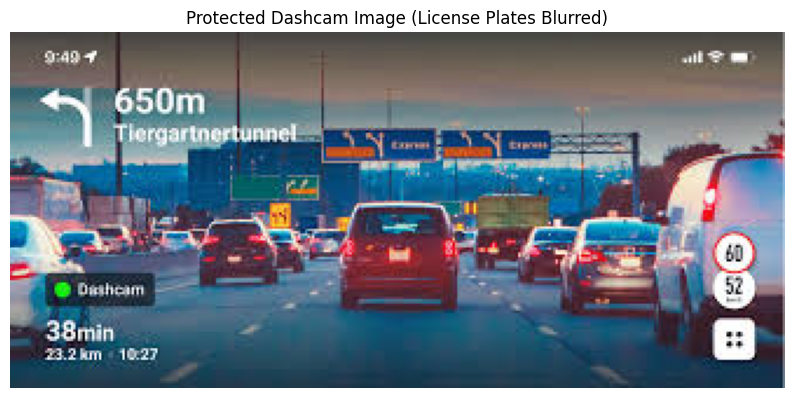

In [32]:
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Protected Dashcam Image (License Plates Blurred)")
plt.axis('off')
plt.show()

In [34]:
# Step 6: Save and download the protected image
output_filename = "protected_dashcam.jpg"
cv2.imwrite(output_filename, image)
print(f"Saved protected image as {output_filename}")
files.download(output_filename)

Saved protected image as protected_dashcam.jpg


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>